# Эволюционные методы оптимизации

## Лекция 1

**Эволюционные алгоритмы** - стохастический популяционный метод поиска, который:
1. поддерживает набор кандидатных решений
2. оценивает их качество
3. **более успешные решения больше влияют на будущие популяции**
4. **создаёт новые варианты с наследованием и случайными изменениямим**
5. формирует следующее поколение
6. прекращает поиск по заданному условию

Если вкратце, то ЭА реализуют 3 механизма:
- **Наследственность**
- **Изменчивость** или **мутация** (добавление доли рандома в новые решения)
- **Естественный отбор**

f(x) → min

F(x) - *fitness функция* или *функция приспособленности*

Допустим, f(x) - путь, который нужно минимизировать, F(x) - функция стоимости пути

### Общий цикл эволюционного алгоритма



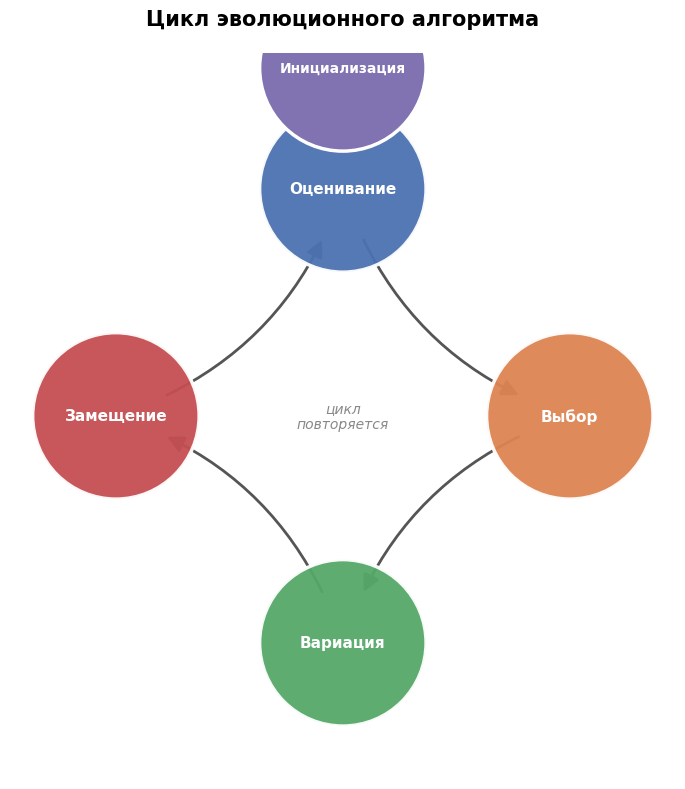

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Circle
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.4, 2.4)
ax.axis('off')
ax.set_aspect('equal')

# --- Стадии основного цикла (по кругу) ---
cycle_stages = ["Оценивание", "Выбор", "Вариация", "Замещение"]
n = len(cycle_stages)
radius = 1.5
angles = [np.pi/2 - 2*np.pi*i/n for i in range(n)]  # старт сверху, по часовой стрелке
positions = {stage: (radius*np.cos(a), radius*np.sin(a)) for stage, a in zip(cycle_stages, angles)}

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# --- Рисуем узлы цикла ---
node_radius = 0.55
for (stage, (x, y)), color in zip(positions.items(), colors):
    circle = Circle((x, y), node_radius, facecolor=color, edgecolor="white",
                     linewidth=2.5, zorder=3, alpha=0.95)
    ax.add_patch(circle)
    ax.text(x, y, stage, ha='center', va='center', fontsize=11,
             fontweight='bold', color='white', zorder=4)

# --- Стрелки между узлами цикла (по кругу, с изгибом) ---
for i in range(n):
    start = positions[cycle_stages[i]]
    end = positions[cycle_stages[(i + 1) % n]]
    arrow = FancyArrowPatch(
        start, end,
        connectionstyle="arc3,rad=0.25",
        arrowstyle="-|>", mutation_scale=25,
        linewidth=2, color="#555555", zorder=2,
        shrinkA=node_radius*72, shrinkB=node_radius*72
    )
    ax.add_patch(arrow)

# --- Узел "Инициализация" (вход в цикл) ---
init_pos = (0, 2.3)
init_color = "#8172B2"
circle_init = Circle(init_pos, node_radius, facecolor=init_color,
                      edgecolor="white", linewidth=2.5, zorder=3)
ax.add_patch(circle_init)
ax.text(*init_pos, "Инициализация", ha='center', va='center',
         fontsize=10, fontweight='bold', color='white', zorder=4)

# Стрелка от Инициализации к первому узлу цикла (Оценивание)
eval_pos = positions["Оценивание"]
arrow_init = FancyArrowPatch(
    init_pos, eval_pos,
    connectionstyle="arc3,rad=0.0",
    arrowstyle="-|>", mutation_scale=25,
    linewidth=2.5, color="#8172B2", zorder=2,
    shrinkA=node_radius*72, shrinkB=node_radius*72
)
ax.add_patch(arrow_init)

# --- Подпись цикла в центре ---
ax.text(0, 0, "цикл\nповторяется", ha='center', va='center',
         fontsize=10, color="#888888", style='italic')

plt.title("Цикл эволюционного алгоритма", fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Пример задачи**:

| Точка | x | f(x) |
| :--- | :---: | :---: |
| **A** | -4 | 25 |
| **B** | -1 | 4 |
| **C** | 2 | 4 |
| **D** | 4 | 9 |

| Точка / Гибрид | Формула расчета x | Значение x | Значение f(x) |
| :--- | :--- | :---: | :---: |
| **x_h1** | 0.5 * (-1) + 0.5 * 2 | 0.5 | 0.25 |
| **x_h2** | 2 - 0.7 | 1.3 | 0.09 |

Вероятность перехода в следующее определяется формулой:

$$p_i = \frac{F(x_i)}{\sum F(x_i)}$$

где $$F(x) = \frac{1}{1 + f(x)}$$

### Найти x* 
2 способа:
1) улучшать найденные решения
2) проверяем области пространства поиска

Если мы только будем улучшать найденные решения (1), то мы будем быстрее будем сходится, но застрянем в локальном оптимуме.

Если будем максимизировать мутацию (2), то получим слишком большое пространство решений и получим худшую сходимость.

## Эволюционнные алгоритмы можно применять, когда:
1. плохой вид функции f(x) (разрывы, много локальных экстремумов)
2. можно выполнить много оценок
3. локальное решение приемлемо
   
Если заданная функция f(x):
1. выпукла, гладкая, есть производная
2. невозможно вычислить качество и проверить ограничения

 используем стандартные методы оптимизации.